In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, load_gbs_gesis, load_gbs_allensbach
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest, train_feature_weighted_decision_tree
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import sample
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs_without_cv, mrs, \
    compute_feature_weights_with_budget, compute_feature_weights_with_temperature
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights

2024-05-08 16:55:55.260183: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-08 16:55:56.267870: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def compute_feature_weights_softmax(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        weights =  np.exp(-feature_importance / budget)
    return weights

def compute_feature_weights(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        max_importance = np.max(feature_importance)
        feature_importance = feature_importance / max_importance 
        scaled_feature_importance = feature_importance * budget
        scaled_feature_importance = 1 + scaled_feature_importance
        return scaled_feature_importance 

In [3]:
def compute_feature_weights_softmax(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        weights =  np.exp(feature_importance / budget)
    return weights

def compute_feature_weights(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        max_importance = np.max(feature_importance)
        feature_importance = feature_importance / max_importance 
        scaled_feature_importance = feature_importance * budget
        scaled_feature_importance = 1 + scaled_feature_importance
        return scaled_feature_importance 

In [26]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
##N = df[df["label"] == 1]
#R = df[df["label"] == 0]
N, R = sample(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.5,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [27]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

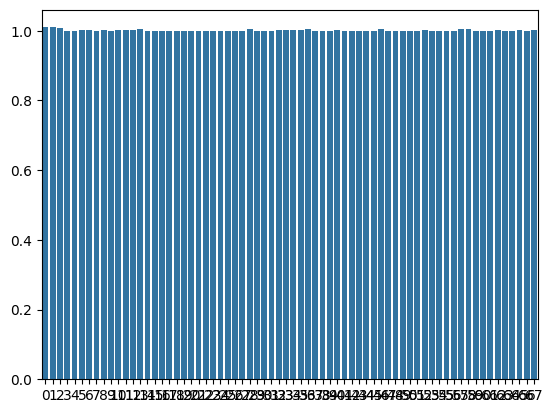

In [40]:
feature_weights = compute_feature_weights(0.01, feature_importance_cv)
sns.barplot((feature_weights))

In [41]:
seed = 5
max_features = "sqrt"
# budgets = [None, 0.01, 0.02, 0.05, 0.075, 0.09, 0.1]
budgets = [None, 1, 0.7, 0.5,  0.25, 0.2]
# budgets = [None, 0.1, 0.01, 0.001]
auroc_method = train_feature_weighted_random_forest
sample_weights = np.ones(len(N))
n_estimators=1000

feature_weights_list = []
for budget in budgets:
    # feature_weights = compute_feature_weights_with_temperature(budget, feature_importance_cv)
    feature_weights = compute_feature_weights(budget, feature_importance_cv)
    # feature_weights = compute_feature_weights_softmax(budget, feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [44]:
for i, budget in enumerate(budgets):
   auroc = compute_test_metrics_fw_mrs(
       dropped_N,
       R,
       columns,
       random_state=seed,
       feature_weights=feature_weights_list[i],
       method=auroc_method,
       class_weight=None,
       max_features="sqrt",
       splitter="feature_weighted_best",
       n_splits_test=10,
       n_estimators=200,
       draw_with_feature_weights=False,
   )
   print(f"{budget}: {auroc}")

None: 0.5269886028257457
1: 0.5042420565149136


KeyboardInterrupt: 

In [ ]:
for i,budget in enumerate(budgets):
    feature_weights = feature_weights_list[i]
    auroc, auprc = compute_classification_metrics_random_forest(
            N,
            R,
            columns,
            sample_weights,
            feature_weights,
            target,
            random_state=seed,
            class_weight=None,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=1000,
            draw_with_feature_weights=True,
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.8211698858647936
None AUPRC: 0.7657652053265336



TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGSEGV(-11)}

None Auroc: 0.8513282582014146\
None AUPRC: 0.8064462637258178

10 Auroc: 0.8518698318055087\
10 AUPRC: 0.8073245735224116

5 Auroc: 0.8517380271452349\
5 AUPRC: 0.8073698448586328

0.7 Auroc: 0.8528511892760596\
0.7 AUPRC: 0.8098015194637058

0.5 Auroc: 0.8538413554739063\
0.5 AUPRC: 0.8099861294396153

0.1 Auroc: 0.842034072157179\
0.1 AUPRC: 0.7926915679157996


In [ ]:
##for i,budget in enumerate(budgets):
    #auroc, auprc = compute_classification_metrics_tree(
            #N,
            #R,
            #columns,
#            sample_weights,
#            feature_weights_list[i],
#            target,
#            random_state=seed,
            #draw_with_feature_weights=True,
#            n_splits=10,
#            splitter="feature_weighted_best",
#            max_features="sqrt",
#    )
#    print(f"{budget} Auroc: {auroc}")
#    print(f"{budget} AUPRC: {auprc}\n")

In [ ]:
# dropped_N = dropped_N.drop(drop_ids)